In [1]:
%load_ext autoreload
%autoreload 2

### Setup

In [2]:
import os, sys
sys.path.append(os.path.dirname(os.getcwd())) # Add the parent directory to sys.path
sys.path.append('/Users/dhei/ai2/new-evals/olmo-repos/olmo/scripts') # Add the parent directory to sys.path

import pandas as pd
import numpy as np

from utils import DATA_DIR
from dataloader import get_nd_array, get_slice

from download.weka import pull_predictions_from_weka

In [3]:
pull_predictions_from_weka("aws")

File already exists and matches size: /Users/dhei/ai2/new-evals/analysis/data/all_aws_predictions.parquet


In [4]:
# df = pd.read_parquet(f'{DATA_DIR}/all_aws_predictions.parquet.bak') # <- 12/11 only OLMES

COLS = ['step', 'model', 'task', 'mix', 'size', 'token_ratio', 'native_id'] 
COLS += ['acc_per_char', 'logits_per_byte', 'correct_choice'] # accuracy benchmarks
# COLS += ['exact_match', 'f1'] # generation benchmarks
# exact_match_simple, recall

df = pd.read_parquet(f'{DATA_DIR}/all_aws_predictions.parquet', columns=COLS)

print(f'Loaded {len(df):,} instance predictions')

Loaded 72,730,000 instance predictions


In [5]:
MODELS = df.index.get_level_values('model').unique().to_list()
TASKS  = df.index.get_level_values('task').unique().to_list()
MIXES  = df.index.get_level_values('mix').unique().to_list()
STEPS  = df.index.get_level_values('step').unique().to_list()

TASKS = [t for t in TASKS if 'mmlu' not in t]
TASKS = sorted(TASKS)

print(MODELS)
print(TASKS)
print(MIXES)
# print(STEPS)

['peteish-moreeval-1B-5xC', 'peteish-moreeval-760M-0.5xC', 'peteish13-highlr', 'peteish7', 'phi-1_5', 'peteish-moreeval-rerun-370M-1xC', 'peteish-moreeval-190M-2xC', 'peteish-moreeval-rerun-190M-1xC', 'peteish-moreeval-1B-2xC', 'falcon_and_cc_eli5_oh_top10p-1B-5xC', 'fineweb_edu_dedup-1B-5xC', 'falcon_and_cc_og_eli5_oh_top10p-1B-5xC', 'no_flan-1B-5xC', 'prox_fineweb_pro-1B-5xC', 'falcon_and_cc-1B-5xC', 'falcon_and_cc_eli5_oh_top20p-1B-5xC', 'baseline-1B-5xC', 'falcon_and_cc_tulu_qc_top10-1B-5xC', 'no_math_no_code-1B-5xC', 'c4-1B-5xC', 'redpajama-1B-5xC', 'no_code-1B-5xC', 'no_reddit-1B-5xC', 'falcon-1B-5xC', 'peteish-moreeval-rerun-760M-1xC', 'peteish-moreeval-370M-2xC', 'DCLM-baseline-1B-5xC', 'dolma17-25p-DCLM-baseline-75p-1B-5xC', 'dolma17-50p-DCLM-baseline-50p-1B-5xC', 'dolma-v1-6-and-sources-baseline-1B-5xC', 'dolma17-75p-DCLM-baseline-25p-1B-5xC', 'peteish-moreeval-760M-10xC', 'peteish-moreeval-3B-10xC', 'peteish-moreeval-rerun-3B-1xC', 'peteish-moreeval-rerun-1B-1xC', 'peteish-m

In [6]:
# models, scores = get_nd_array(df, 'model', 'acc_per_char', task='arc_challenge:distractors')
# models, scores = get_nd_array(df, ['model', 'mix'], 'acc_per_char', task='arc_challenge:distractors')

In [7]:
# OLMES Classic Tasks
from utils.constants_tasks import RC_TASKS_OLMES, PARA_TASKS_OLMES, ENLARGE_TASKS_OLMES, DISTRACTORS_TASKS_OLMES

# OLMES Gen Tasks
from utils.constants_tasks import GEN_TASKS_OLMES, GEN_TASKS_OLMES_PERTURB_RC

# CoT tasks (mainly Tulu tasks)
from utils.constants_tasks import AGI_EVAL_MC, AGI_EVAL_COT
from utils.constants_tasks import MMLU_PRO_MC, MMLU_PRO_RC, MMLU_PRO_COT
from utils.constants_tasks import MINERVA_MC, MINERVA_COT
from utils.constants_tasks import BBH_MC, BBH_COT
from utils.constants_tasks import PERTURB_COT_TASKS

def task_tag(task_name):
    return task_name.split('::')[0].replace(':rc', '')

# Select task set
selected_tasks = RC_TASKS_OLMES + PARA_TASKS_OLMES + ENLARGE_TASKS_OLMES + DISTRACTORS_TASKS_OLMES
# selected_tasks = MC_TASKS_COPY_COLORS
# selected_tasks = GEN_TASKS_OLMES + GEN_TASKS_OLMES_PERTURB_RC
# selected_tasks = AGI_EVAL_MC + AGI_EVAL_COT + MMLU_PRO_MC + MMLU_PRO_RC + MMLU_PRO_COT + MINERVA_COT + BBH_MC + BBH_COT + PERTURB_COT_TASKS

TASKS = [task_tag(task) for task in selected_tasks]

TASKS = [task for task in TASKS if 'mmlu_' not in task]

# Get task suites
olmes = [task_tag(task) for task in RC_TASKS_OLMES if 'mmlu_' not in task]

# TODO: Add olmes_avg and it's variants to TASKS
# TODO: Add mmlu macro avg as a single task!

### Measure 1: Predictability (Rel Error @ 7B)

In [8]:
import matplotlib.pyplot as plt

# https://arxiv.org/pdf/2412.04403#page=3.57
LADDER_MODELS = [model for model in MODELS if 'peteish-moreeval' in model]

# For the paper, we did not use 3B or 0.5xC models
akshita_ladder_models = [
    model for model in LADDER_MODELS if "3B" not in model and "0.5xC" not in model
]

In [9]:
from ladder import get_ladder_data
plt.close('all') # silence output

# Example of grabbing ladder data
data_by_name = get_ladder_data(
    df, task_name="arc_challenge", train_models=LADDER_MODELS, eval_models=["peteish7"]
)

In [10]:
# Sanity check for task results
task_name = 'arc_challenge:distractors'
model = 'peteish13-highlr'
m2, bpb  = get_nd_array(df, 'model', 'logits_per_byte', model=model, task=task_name, step='max')
data_by_name = get_ladder_data(df, [task_name], LADDER_MODELS, [model])

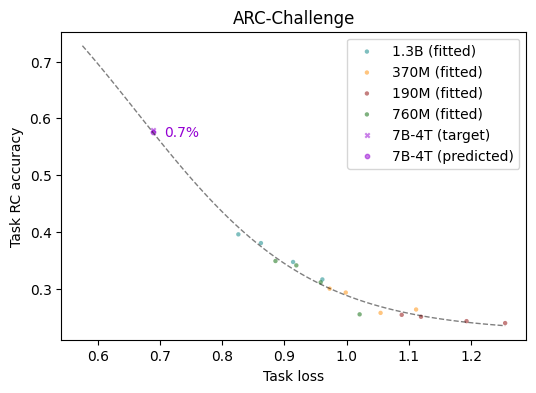

In [11]:
from ladder import run_ladder_step_2

# python scripts/scaling/step2.py -k v2_main -c scripts/scaling/step2.json -o figure/peteish-moreeval/step2_main.pdf --skip_perc 1

fig, axes = plt.subplots(1, 1, figsize=(6, 4), squeeze=False)
y, y_pred, rel_error, delta_error = run_ladder_step_2(
    df,
    train_models=akshita_ladder_models,
    eval_models=["peteish7"],
    task_name="arc_challenge",
    # eval_models=["peteish13-highlr"],
    # task_name="agi_eval_aqua-rat:perturb_cot",
    ax=axes[0][0],
)
_ = axes[0][0].set_title('ARC-Challenge')

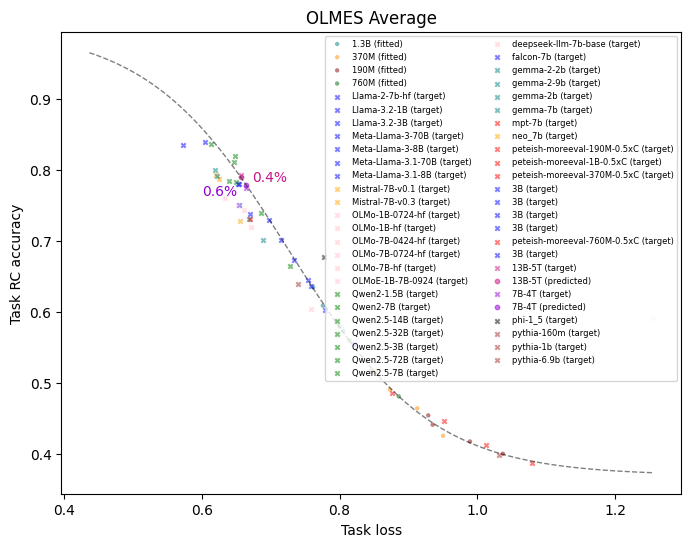

In [12]:
from utils.constants_models import MODEL_LIST_MIXES

MODEL_LIST_MIXES = [model.split("/")[-1] for model in MODEL_LIST_MIXES]
BROKEN_MODELS = ['Llama-2-13b-hf']
all_models = sorted([model for model in MODELS if model not in MODEL_LIST_MIXES + BROKEN_MODELS + akshita_ladder_models])

fig, axes = plt.subplots(1, 1, figsize=(8, 6), squeeze=False)
y, y_pred, rel_error, delta_error = run_ladder_step_2(
    df,
    # task_name="arc_challenge",
    task_name=[olmes],
    train_models=akshita_ladder_models,
    eval_models=all_models,
    ax=axes[0][0],
)
axes[0][0].set_title('OLMES Average')
_ = axes[0][0].legend(fontsize=6, ncol=2)

In [13]:
from tqdm import tqdm

num_rows, num_cols = len(TASKS), 1
fig, axes = plt.subplots(num_rows, num_cols, figsize=(6 * num_cols, 4 * num_rows), squeeze=False)

fitting_results = pd.DataFrame(index=['rel_error'], columns=TASKS)

for i, task in tqdm(enumerate(TASKS), desc='Fitting model ladder predictions', total=len(TASKS)):
    ax: plt.Axes = axes[i, 0]

    try:
        y, y_pred, rel_error, delta_error = run_ladder_step_2(
            df, 
            task_name=task, 
            train_models=akshita_ladder_models, 
            # eval_models=['peteish7'], 
            eval_models=['peteish13-highlr'], 
            ax=ax
        )

        ax.set_title(task)
        ax.legend(fontsize=4, ncol=2)

        task_name = task
        if isinstance(task, list):
            task_name = 'olmes_macro_average'

        fitting_results.loc['rel_error', task_name] = abs(rel_error)
    except Exception as e:
        print(f'{task} failed: {e}')
        continue

fig.tight_layout()

plt.close(fig)

Fitting model ladder predictions: 100%|██████████| 34/34 [01:22<00:00,  2.42s/it]


In [14]:
from table import display_task_variants

print(f'Relative error predicting performance of 7B using only final checkpoints of ladder models up to 1B-10xC:')
display_task_variants(fitting_results, key='rel_error', inverse=True, ascending=True)

Relative error predicting performance of 7B using only final checkpoints of ladder models up to 1B-10xC:


Variant,default rc,distractors,enlarge,para
Task,,,,
piqa,0.8%,18.1% (+17.3%),1.4% (+0.6%),1.5% (+0.7%)
hellaswag,0.9%,4.3% (+3.4%),3.9% (+3.0%),3.4% (+2.5%)
arc_easy,3.1%,2.5% (-0.6%),8.0% (+4.9%),2.6% (-0.5%)
csqa,3.7%,9.2% (+5.5%),2.7% (-1.0%),1.5% (-2.2%)
socialiqa,4.7%,20.3% (+15.6%),2.1% (-2.6%),7.6% (+3.0%)
arc_challenge,5.6%,7.5% (+1.9%),8.3% (+2.7%),6.5% (+0.9%)
openbookqa,8.2%,1.2% (-7.0%),4.3% (-3.9%),9.8% (+1.6%)
boolq,13.7%,11.6% (-2.0%),2.0% (-11.7%),16.1% (+2.5%)
winogrande,26.5%,--,--,20.3% (-6.1%)


### Measure 2: Seperability (% sig @ 1B)

Explanation of a paired permutation test:


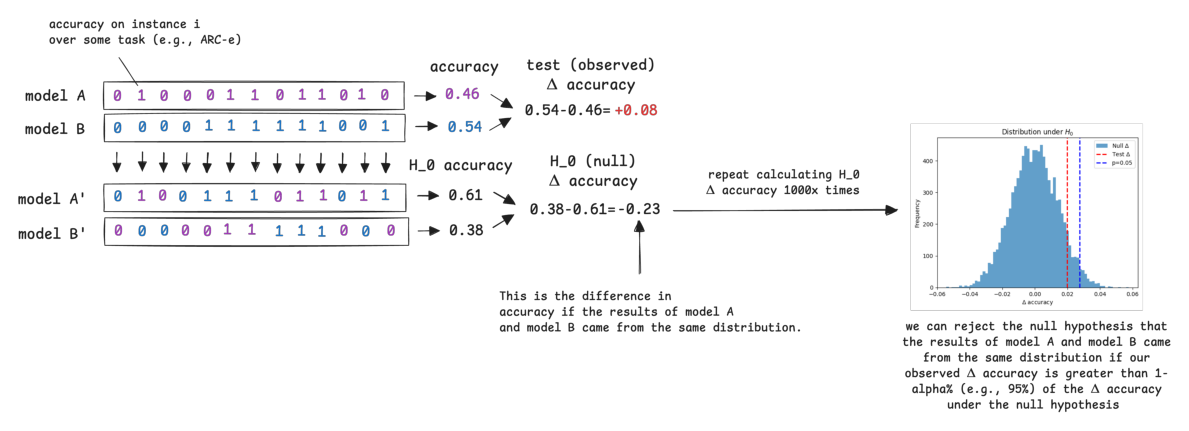

In [15]:
from PIL import Image
import matplotlib.pyplot as plt

def display_image(path, max_width=1200):
    img = Image.open(path)
    plt.figure(figsize=(min(max_width/100, img.width/100), img.height/100))
    plt.imshow(plt.imread(path))
    plt.axis('off')
    plt.tight_layout()
    plt.show()


print('Explanation of a paired permutation test:')
os.chdir('/Users/dhei/ai2/new-evals/analysis/notebooks')
display_image('assets/paired-permutation-test.png')

In [16]:
from stats import compute_significance
from utils.constants_models import MODEL_LIST_MIXES

MODEL_LIST_MIXES = [model.split('/')[-1] for model in MODEL_LIST_MIXES]

Computing pairwise comparisons: 100%|██████████| 1/1 [00:00<00:00,  2.23it/s]


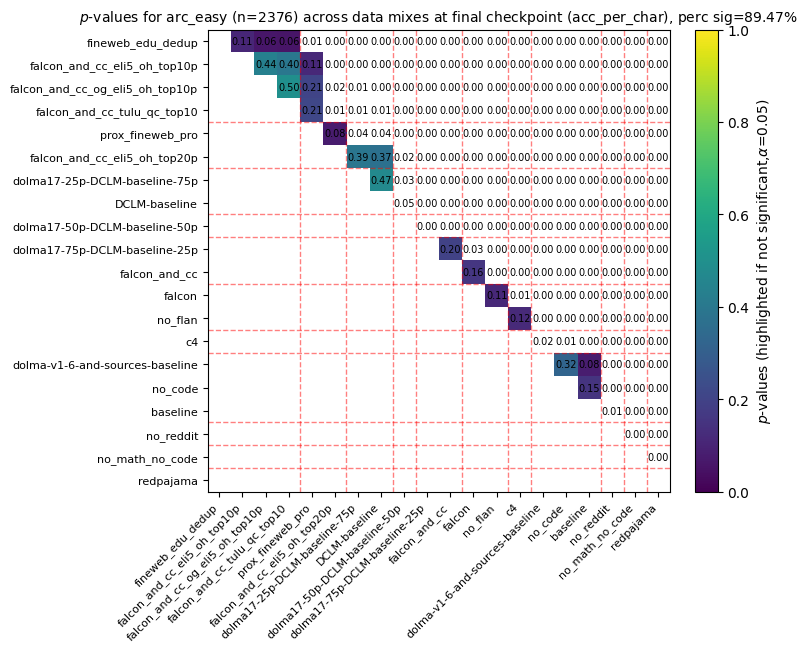

In [17]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6), squeeze=False)

sig_results, _, ax = compute_significance(
    df, 
    models=MODEL_LIST_MIXES, 
    metric='acc_per_char', 
    tasks=['arc_easy'], 
    do_plot=axes[0][0]
)

In [18]:
sig_results, _, _ = compute_significance(
    df, 
    models=MODEL_LIST_MIXES, 
    metric='acc_per_char', 
    # tasks='arc_easy',
    tasks=TASKS,
    do_plot=False
)

Computing pairwise comparisons: 100%|██████████| 34/34 [00:17<00:00,  1.91it/s]


In [19]:
from table import display_task_variants

print('% of significant comparisons for 1B-5xC models on 20 data mixes:')
display_task_variants(sig_results, key='perc_sig')

% of significant comparisons for 1B-5xC models on 20 data mixes:


Variant,default rc,distractors,enlarge,para
Task,,,,
arc_easy,89.5%,91.1% (+1.6%),95.3% (+5.8%),84.7% (-4.7%)
hellaswag,87.4%,59.5% (-27.9%),77.9% (-9.5%),79.5% (-7.9%)
csqa,79.5%,81.6% (+2.1%),93.7% (+14.2%),51.6% (-27.9%)
arc_challenge,73.7%,75.3% (+1.6%),90.5% (+16.8%),76.3% (+2.6%)
boolq,70.5%,86.3% (+15.8%),96.3% (+25.8%),78.9% (+8.4%)
socialiqa,55.3%,72.6% (+17.4%),78.4% (+23.2%),41.6% (-13.7%)
openbookqa,48.9%,28.4% (-20.5%),93.2% (+44.2%),48.9% (+0.0%)
piqa,33.2%,16.3% (-16.8%),79.5% (+46.3%),28.4% (-4.7%)
winogrande,23.7%,--,--,23.2% (-0.5%)


### Measure 3: Smoothness (Total Variation @ 1B)

In [20]:
from stats import compute_total_variation

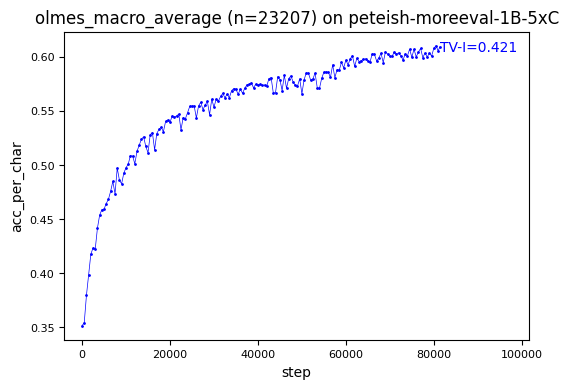

In [21]:
fig, axes = plt.subplots(1, 1, figsize=(6, 4), squeeze=False)

tv_results, _ = compute_total_variation(
    df, 
    tasks=[olmes],
    models='peteish-moreeval-1B-5xC',
    metric='acc_per_char',
    ax=axes[0][0]
)

In [22]:
tv_results, _ = compute_total_variation(
    df, 
    tasks=TASKS,
    models='peteish-moreeval-1B-5xC',
    metric='acc_per_char',
)

In [23]:
print(f'TV-I for intermediate checkpoints on 1B 5xC peteish ladder (OLMoE mix):')
display_task_variants(tv_results, key='total_variation', as_prct=False, inverse=True, ascending=True)

TV-I for intermediate checkpoints on 1B 5xC peteish ladder (OLMoE mix):


Variant,default rc,distractors,enlarge,para
Task,,,,
hellaswag,0.17,0.28 (+0.11),0.32 (+0.15),0.18 (+0.01)
piqa,0.37,0.36 (-0.01),0.47 (+0.10),0.38 (+0.01)
socialiqa,0.50,0.65 (+0.16),0.95 (+0.45),0.57 (+0.07)
arc_easy,0.53,0.59 (+0.06),0.64 (+0.11),0.43 (-0.10)
csqa,0.56,0.80 (+0.24),0.51 (-0.05),0.67 (+0.11)
winogrande,0.62,--,--,0.67 (+0.05)
arc_challenge,0.67,0.67 (+0.00),0.49 (-0.18),0.72 (+0.05)
openbookqa,0.93,0.68 (-0.25),1.31 (+0.39),1.03 (+0.10)
boolq,3.56,3.63 (+0.07),6.09 (+2.53),1.13 (-2.43)


### All 3 Measures

In [24]:
print(f'Relative error predicting performance of 7B using only final checkpoints of ladder models up to 1B-10xC:')
display_task_variants(fitting_results, key='rel_error', inverse=True, ascending=True)

print('% of significant comparisons for 1B-5xC models on 20 data mixes:')
display_task_variants(sig_results, key='perc_sig')

print(f'TV-I for intermediate checkpoints on 1B 5xC peteish ladder (OLMoE mix):')
display_task_variants(tv_results, key='total_variation', as_prct=False, inverse=True, ascending=True)

Relative error predicting performance of 7B using only final checkpoints of ladder models up to 1B-10xC:


Variant,default rc,distractors,enlarge,para
Task,,,,
piqa,0.8%,18.1% (+17.3%),1.4% (+0.6%),1.5% (+0.7%)
hellaswag,0.9%,4.3% (+3.4%),3.9% (+3.0%),3.4% (+2.5%)
arc_easy,3.1%,2.5% (-0.6%),8.0% (+4.9%),2.6% (-0.5%)
csqa,3.7%,9.2% (+5.5%),2.7% (-1.0%),1.5% (-2.2%)
socialiqa,4.7%,20.3% (+15.6%),2.1% (-2.6%),7.6% (+3.0%)
arc_challenge,5.6%,7.5% (+1.9%),8.3% (+2.7%),6.5% (+0.9%)
openbookqa,8.2%,1.2% (-7.0%),4.3% (-3.9%),9.8% (+1.6%)
boolq,13.7%,11.6% (-2.0%),2.0% (-11.7%),16.1% (+2.5%)
winogrande,26.5%,--,--,20.3% (-6.1%)


% of significant comparisons for 1B-5xC models on 20 data mixes:


Variant,default rc,distractors,enlarge,para
Task,,,,
arc_easy,89.5%,91.1% (+1.6%),95.3% (+5.8%),84.7% (-4.7%)
hellaswag,87.4%,59.5% (-27.9%),77.9% (-9.5%),79.5% (-7.9%)
csqa,79.5%,81.6% (+2.1%),93.7% (+14.2%),51.6% (-27.9%)
arc_challenge,73.7%,75.3% (+1.6%),90.5% (+16.8%),76.3% (+2.6%)
boolq,70.5%,86.3% (+15.8%),96.3% (+25.8%),78.9% (+8.4%)
socialiqa,55.3%,72.6% (+17.4%),78.4% (+23.2%),41.6% (-13.7%)
openbookqa,48.9%,28.4% (-20.5%),93.2% (+44.2%),48.9% (+0.0%)
piqa,33.2%,16.3% (-16.8%),79.5% (+46.3%),28.4% (-4.7%)
winogrande,23.7%,--,--,23.2% (-0.5%)


TV-I for intermediate checkpoints on 1B 5xC peteish ladder (OLMoE mix):


Variant,default rc,distractors,enlarge,para
Task,,,,
hellaswag,0.17,0.28 (+0.11),0.32 (+0.15),0.18 (+0.01)
piqa,0.37,0.36 (-0.01),0.47 (+0.10),0.38 (+0.01)
socialiqa,0.50,0.65 (+0.16),0.95 (+0.45),0.57 (+0.07)
arc_easy,0.53,0.59 (+0.06),0.64 (+0.11),0.43 (-0.10)
csqa,0.56,0.80 (+0.24),0.51 (-0.05),0.67 (+0.11)
winogrande,0.62,--,--,0.67 (+0.05)
arc_challenge,0.67,0.67 (+0.00),0.49 (-0.18),0.72 (+0.05)
openbookqa,0.93,0.68 (-0.25),1.31 (+0.39),1.03 (+0.10)
boolq,3.56,3.63 (+0.07),6.09 (+2.53),1.13 (-2.43)


Computing pairwise comparisons: 100%|██████████| 1/1 [00:00<00:00,  1.51it/s]


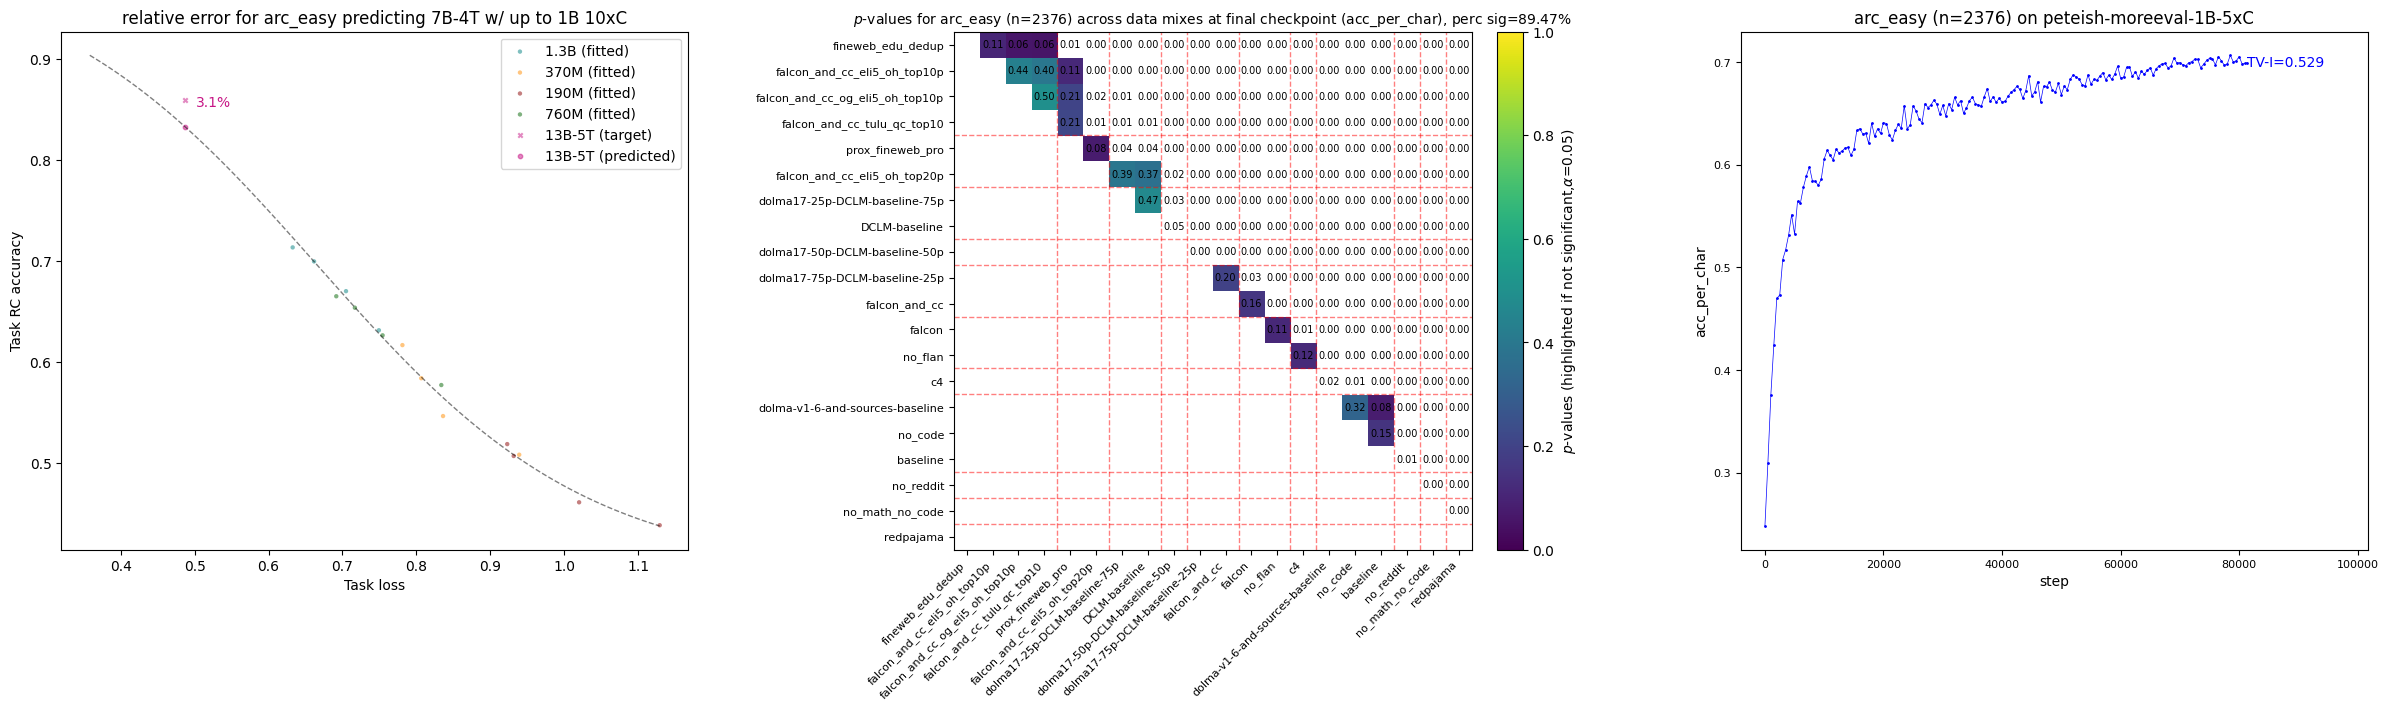

In [25]:
def plot_all_measures(task_name):
    fig, axes = plt.subplots(1, 3, figsize=(8*3, 7), squeeze=False)

    # Measure 1: Predictability
    y, y_pred, rel_error, delta_error = run_ladder_step_2(
        df,
        task_name=task_name,
        train_models=akshita_ladder_models,
        # eval_models=all_models,
        eval_models=['peteish13-highlr'],
        # eval_models=['peteish7', 'peteish13-highlr'],
        ax=axes[0][0],
    )
    # _ = axes[0][0].legend(fontsize=6, ncol=2)
    _task_name = task_name if isinstance(task_name, str) else 'aggregate'
    axes[0][0].set_title(f'relative error for {_task_name} predicting 7B-4T w/ up to 1B 10xC')

    # Measure 2: Seperability
    sig_results, _, ax = compute_significance(
        df, 
        models=MODEL_LIST_MIXES, 
        metric='acc_per_char', 
        tasks=[task_name], 
        do_plot=axes[0][1]
    )

    # Measure 3: Smoothness
    tv_results, _ = compute_total_variation(
        df, 
        models='peteish-moreeval-1B-5xC',
        # metric='logits_per_char',
        metric='acc_per_char',
        tasks=[task_name],
        ax=axes[0][2]
    )

    fig.tight_layout()

    return fig

_ = plot_all_measures('arc_easy')
# _ = plot_all_measures(olmes)

# _ = plot_all_measures('agi_eval_sat-math:mc')
# _ = plot_all_measures('agi_eval_sat-math:perturb_cot')

# _ = plot_all_measures('agi_eval_aqua-rat:mc')
# _ = plot_all_measures('agi_eval_aqua-rat:perturb_cot')

# _ = plot_all_measures('minerva_math_algebra:perturb_cot')

Computing pairwise comparisons: 100%|██████████| 1/1 [00:00<00:00,  2.11it/s]


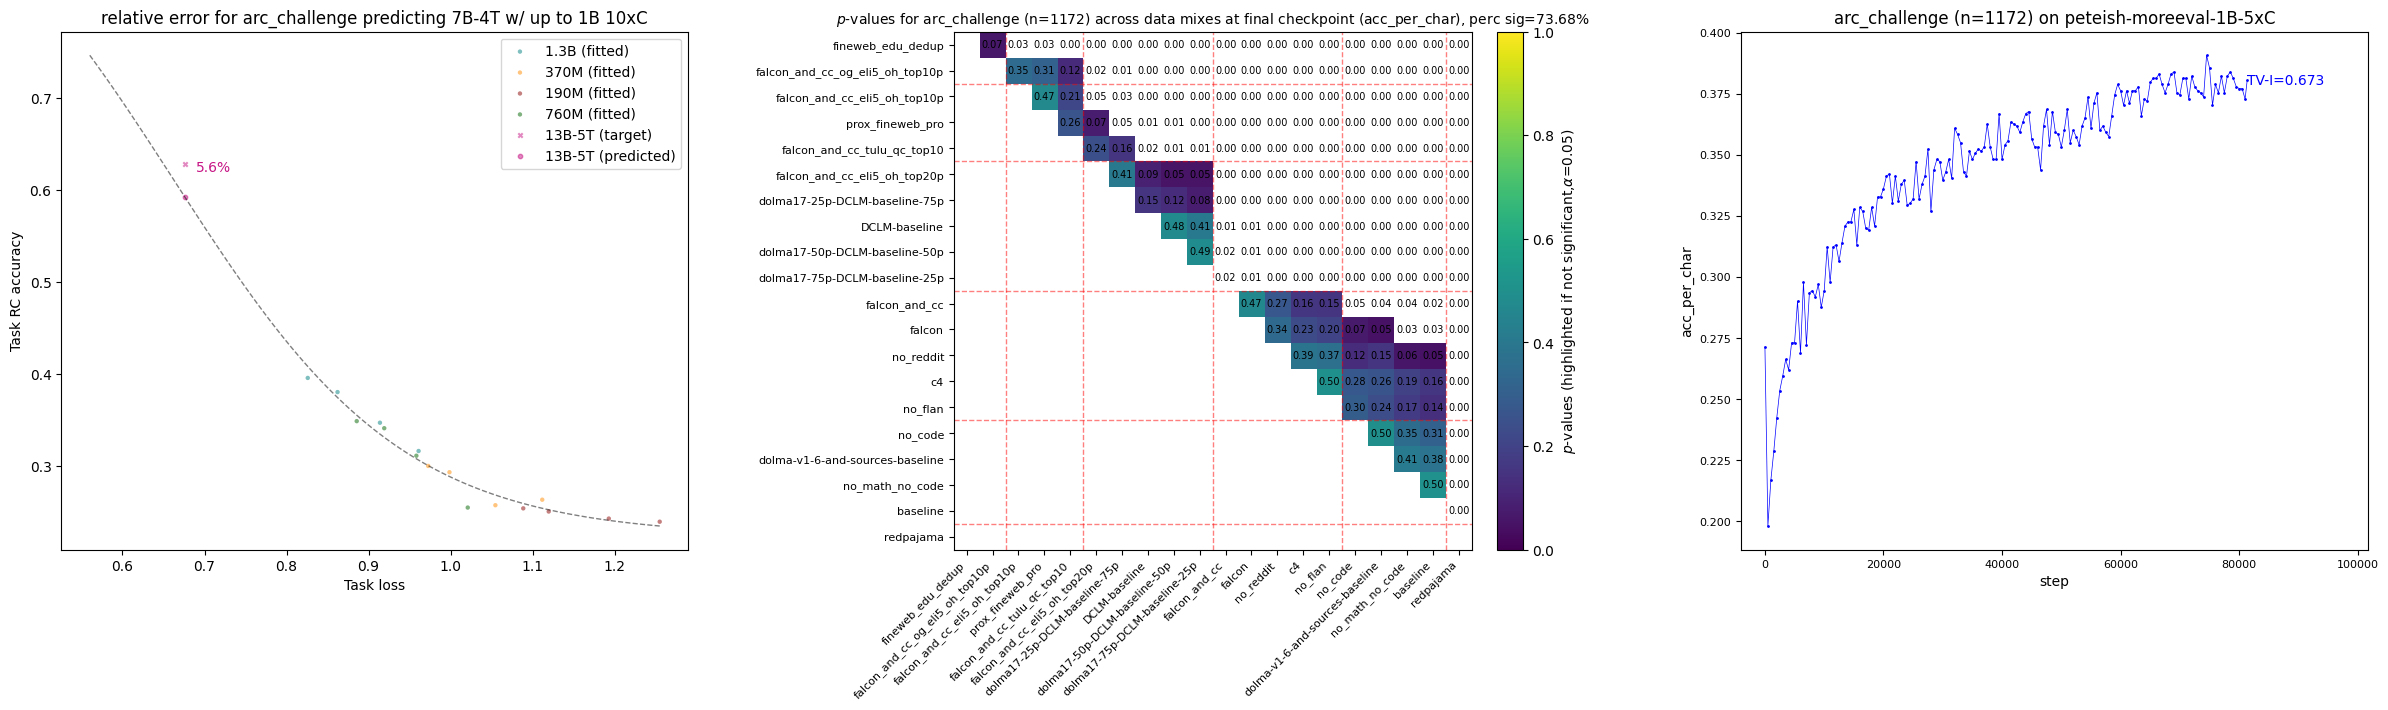

In [26]:
_ = plot_all_measures('arc_challenge')

Computing pairwise comparisons: 100%|██████████| 1/1 [00:00<00:00,  2.25it/s]


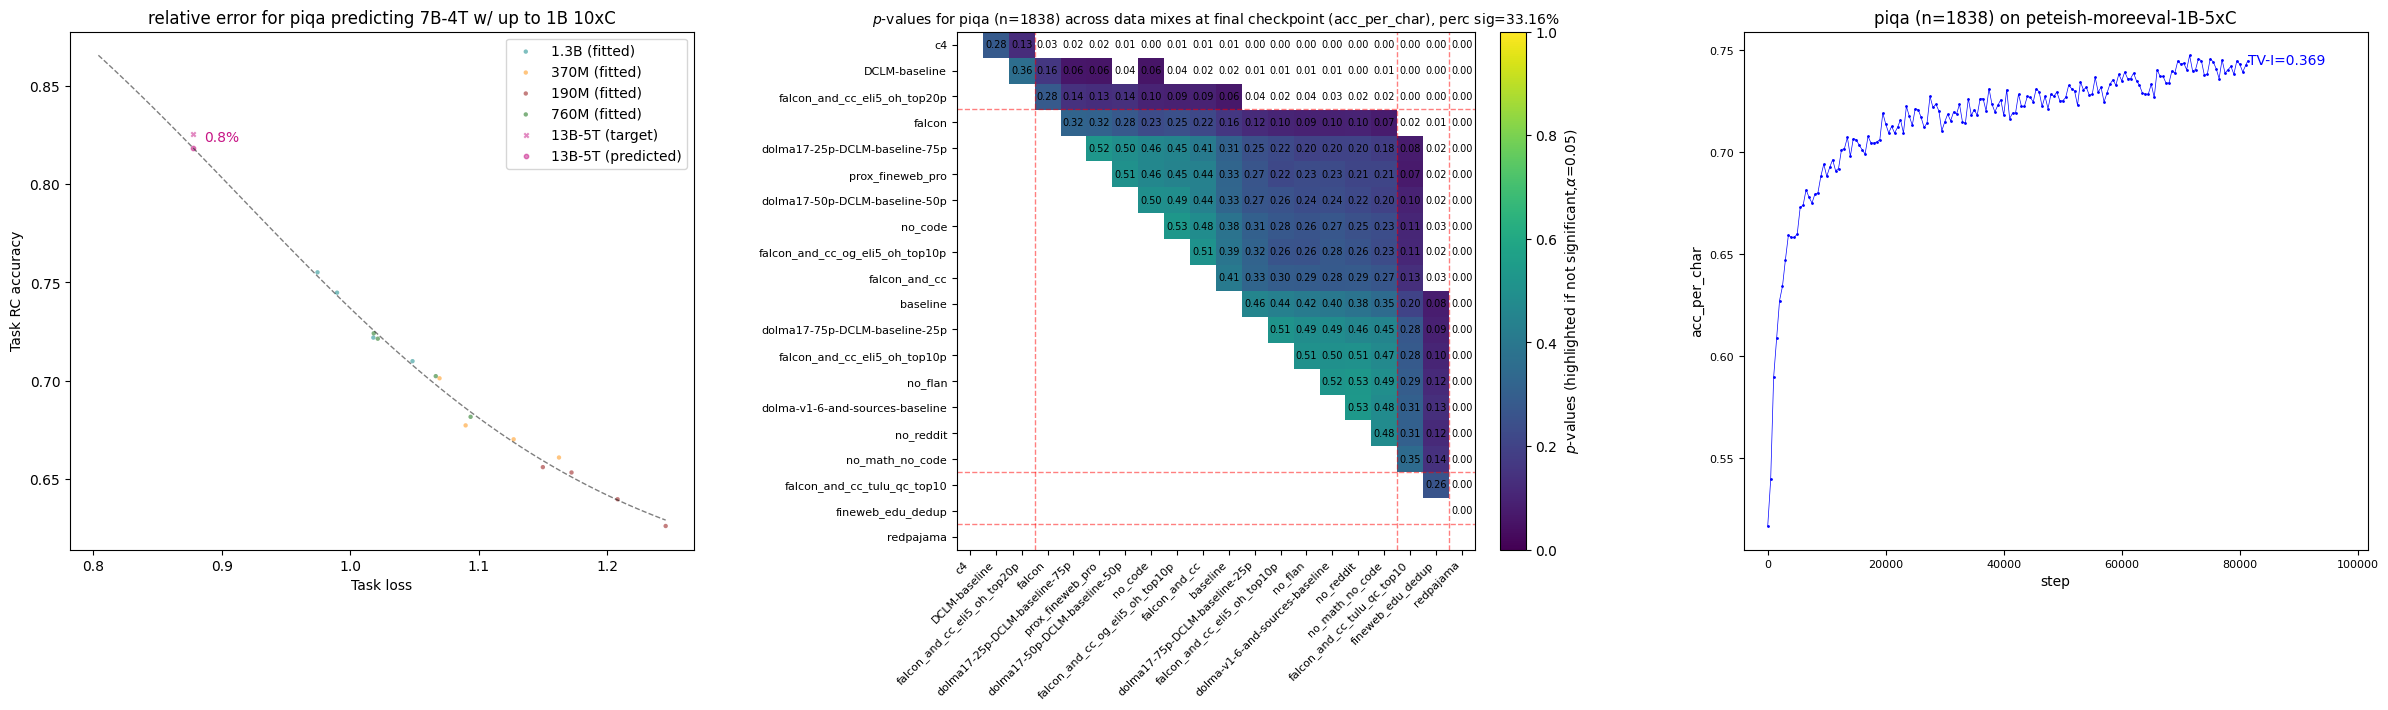

In [27]:
_ = plot_all_measures('piqa')

Computing pairwise comparisons: 100%|██████████| 1/1 [00:00<00:00,  2.34it/s]


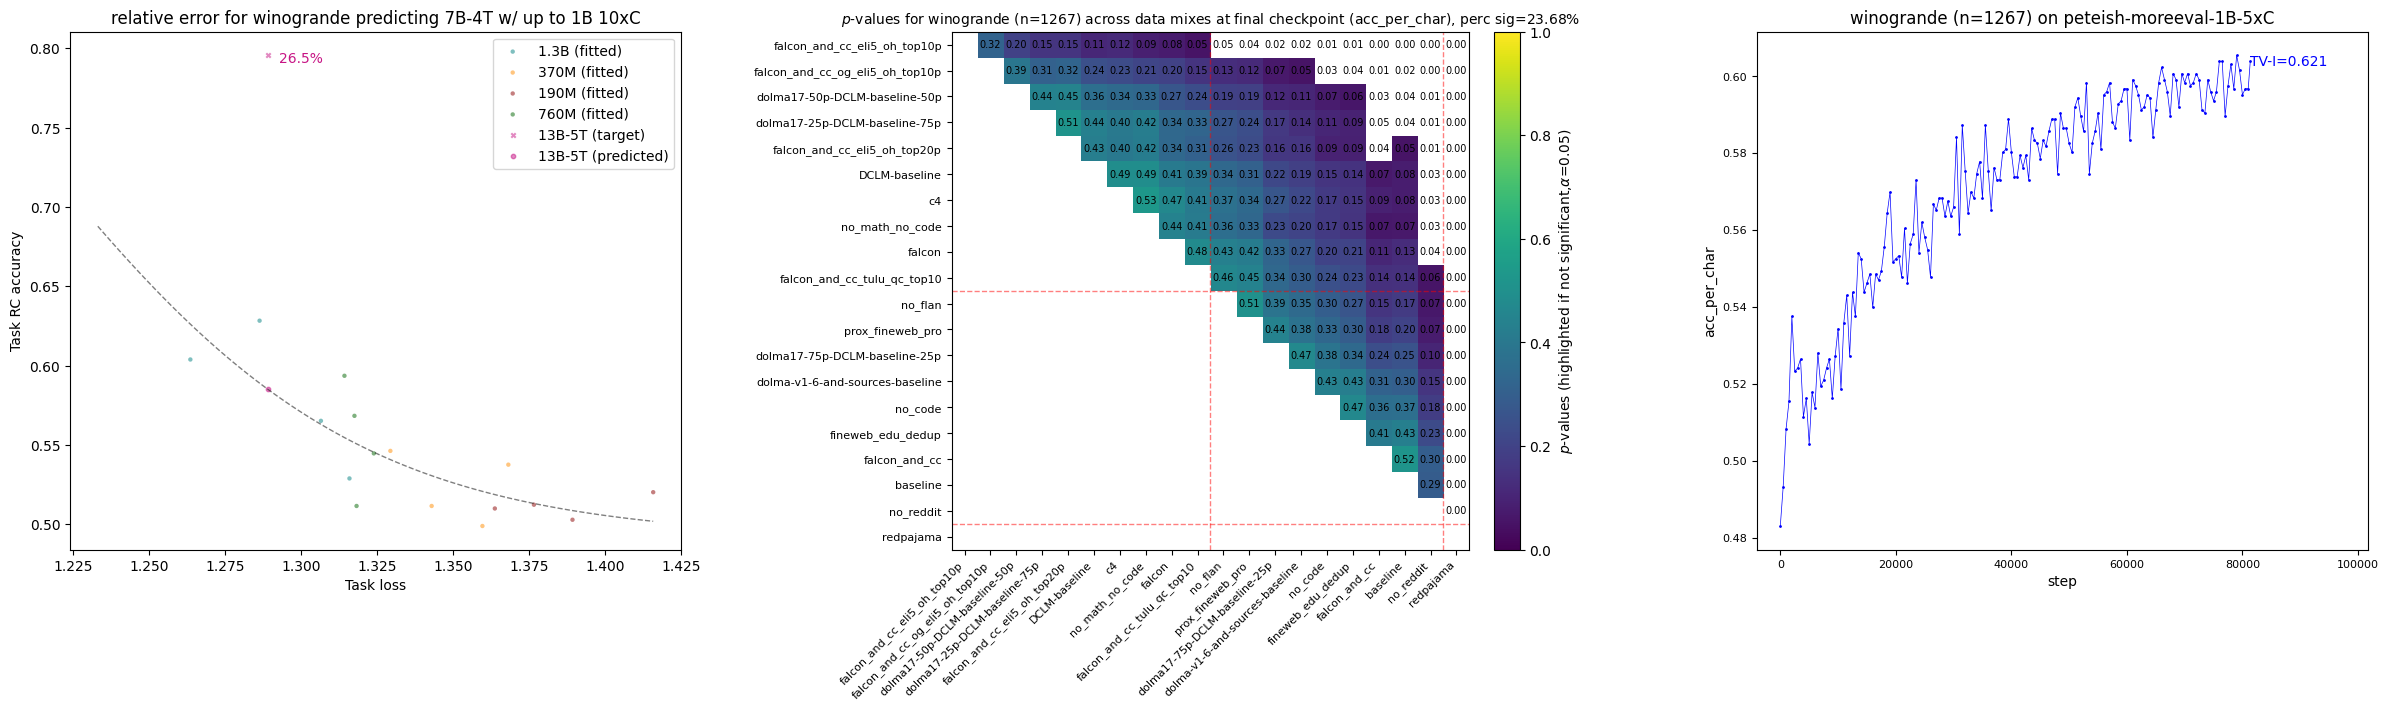

In [28]:
_ = plot_all_measures('winogrande')

### Benchmark Transformations

Computing pairwise comparisons: 100%|██████████| 1/1 [00:00<00:00,  2.01it/s]


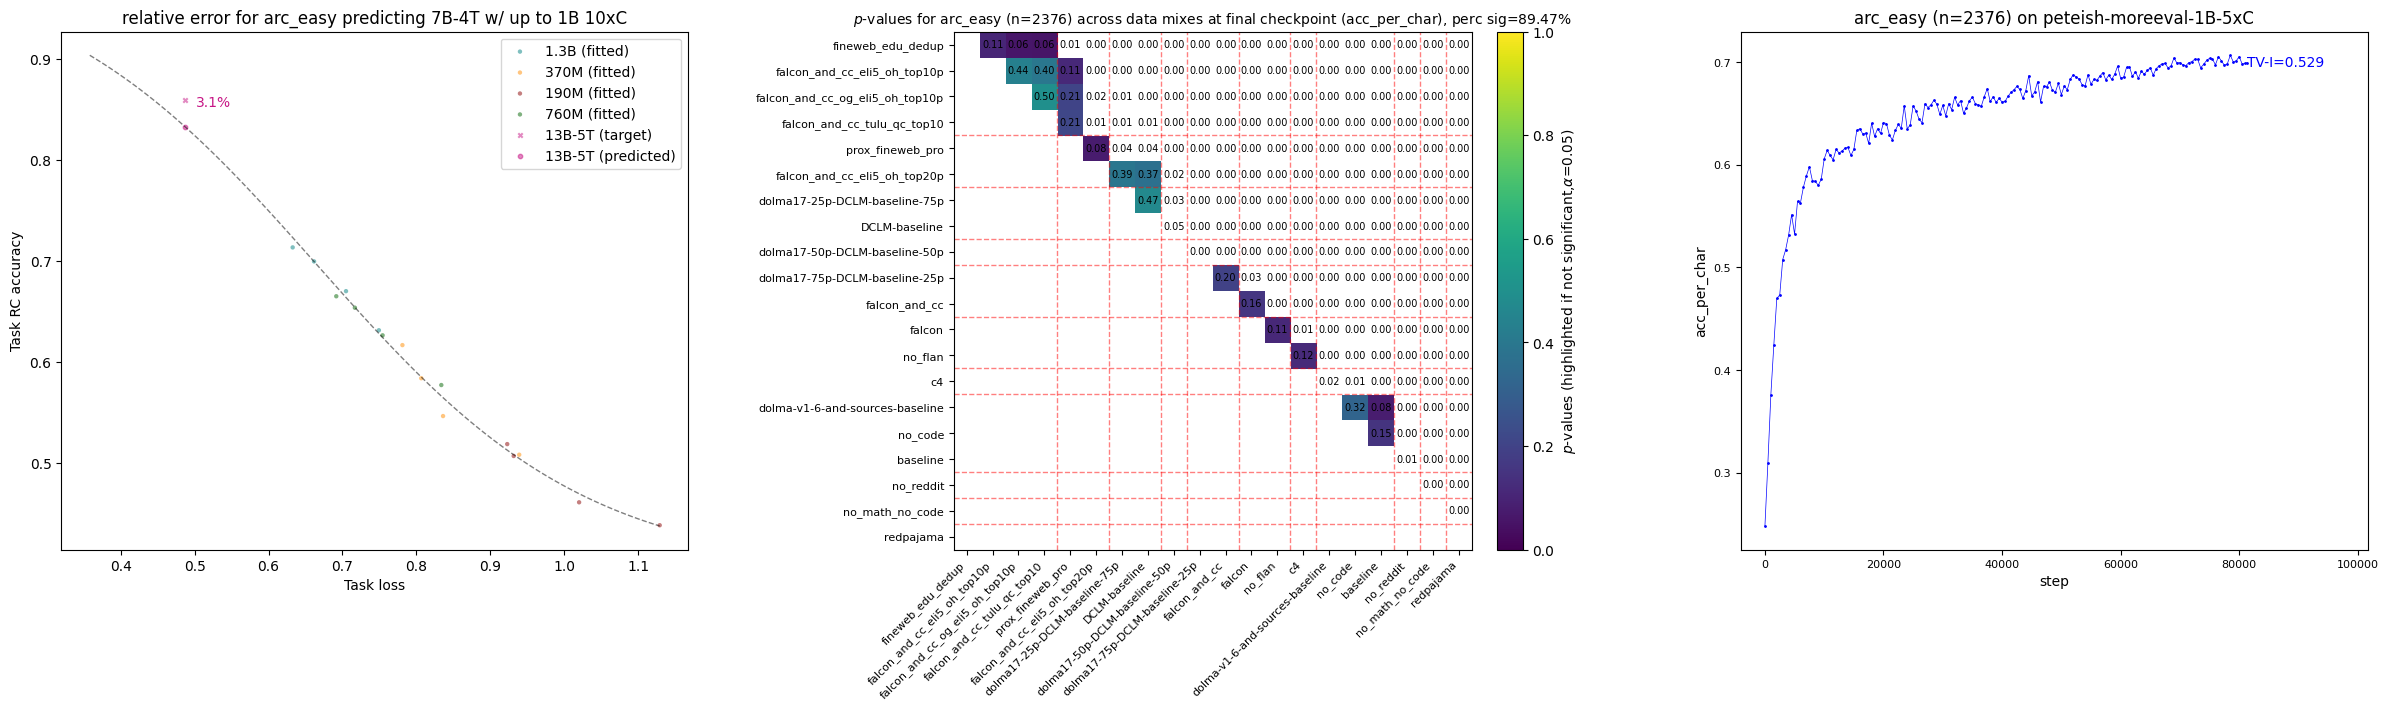

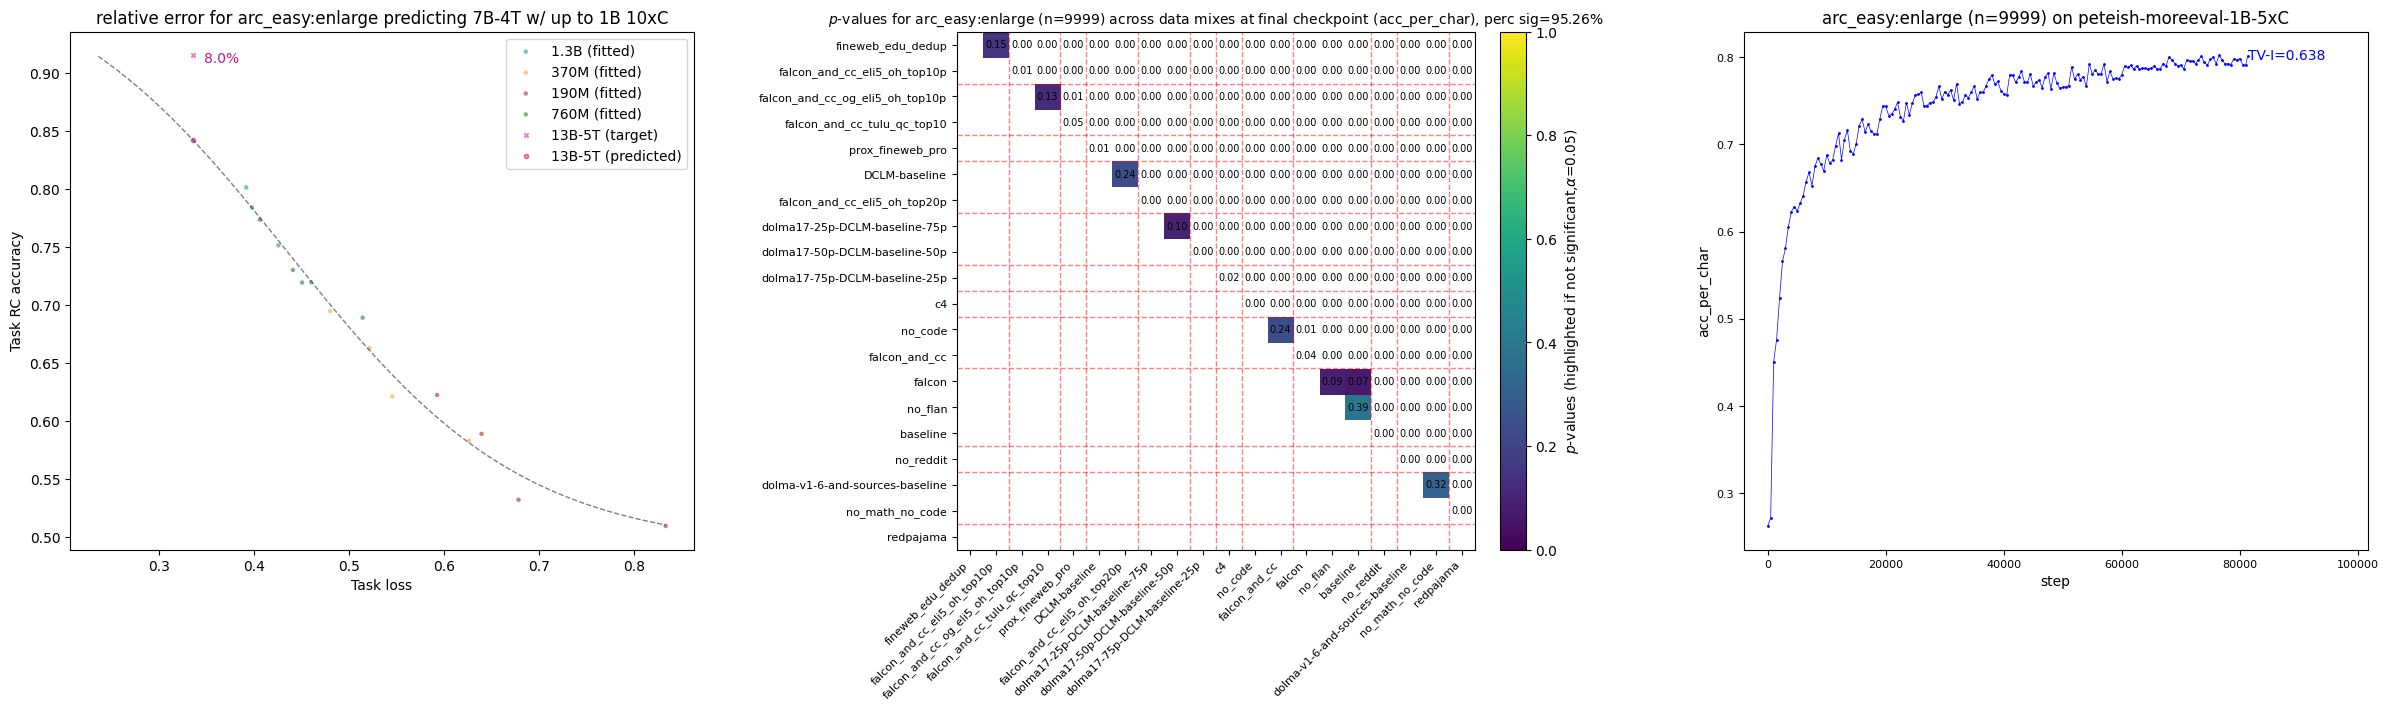

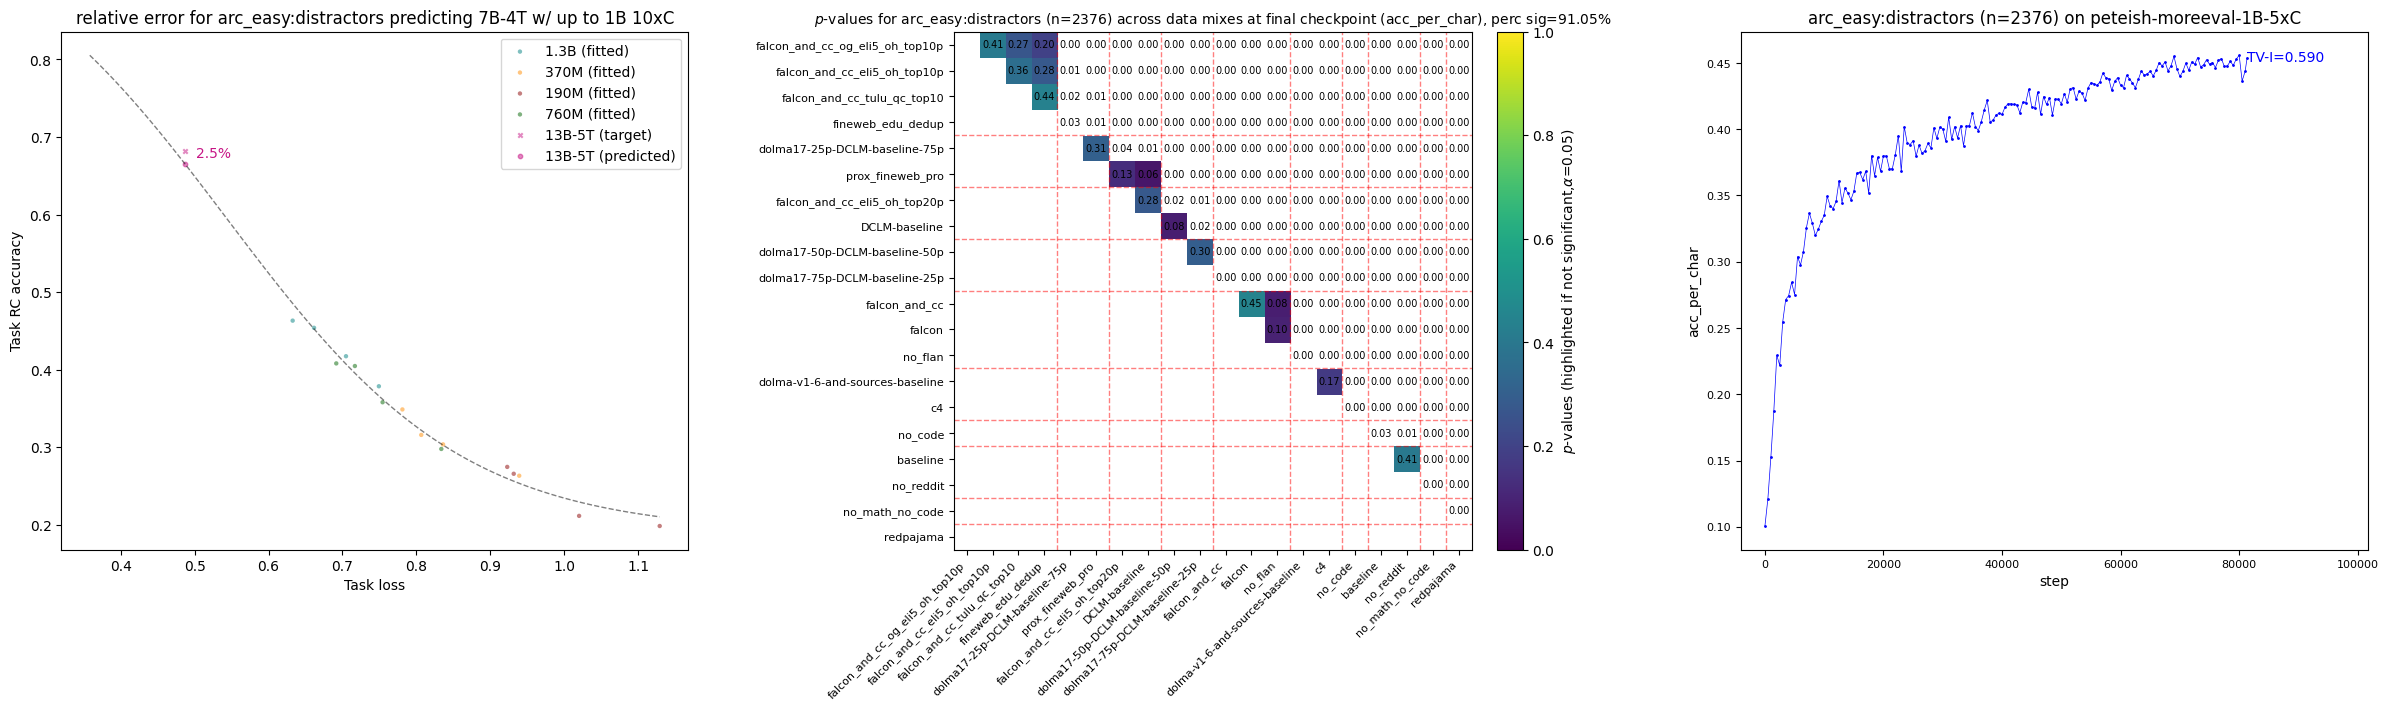

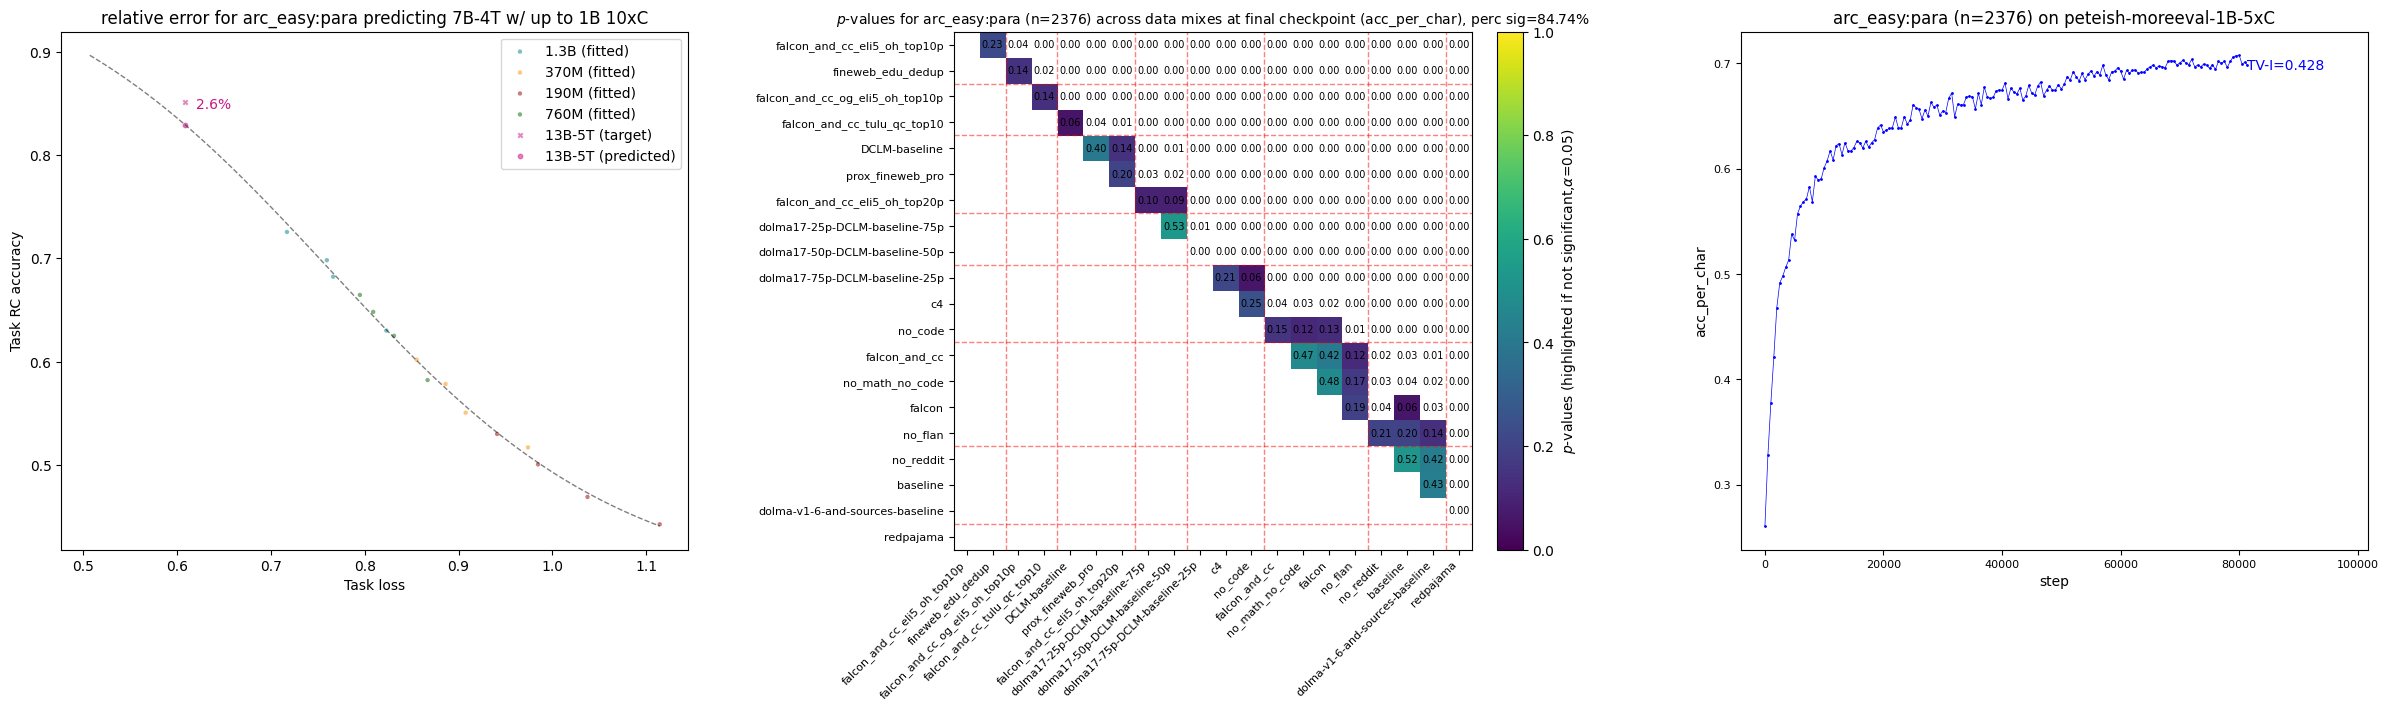

In [29]:
_ = plot_all_measures('arc_easy')
_ = plot_all_measures('arc_easy:enlarge')
_ = plot_all_measures('arc_easy:distractors')
_ = plot_all_measures('arc_easy:para')

### Results on All Tasks

In [30]:
# for task in tqdm(TASKS, desc='Plotting all tasks'):
#     try:
#         _ = plot_all_measures(task)
#     except Exception as e:
#         print(f'{task} failed: {e}')

In [31]:
# TODO: Use bootstrap sampling to see how these numbers change as we increase sample size

### Under Development: Step 1 Predictions

In [32]:
from olmo.scaling.scaling_laws.utils import get_final_configs, get_step2_data_by_name, get_task_sets
from scaling.step2 import main as step2_main
from scaling.step2 import fit_step2, predict_step2, plot_step2

os.chdir('/Users/dhei/ai2/new-evals/olmo-repos/OLMo')

config_path = "scripts/scaling/final.json"
# config_path = "scripts/scaling/final_7b_only.json"

configs = get_final_configs(config_path)
task_names = get_task_sets(["v2_main_variance"])

data_by_name = get_step2_data_by_name(
    configs,
    'arc_easy_test_5shot',
    x_metric='rc_bpb',
    y_metric='rc_acc',
    moving_avg=5,
    skip_perc=0.1,
)

coefficients, cov = fit_step2(data_by_name, 'arc_easy_test_5shot', 'rc_acc', use_log_sigmoid=False)

(
    predicted_data_by_name, plotted_predicted_data,
    (y, y_pred, rel_error, delta_error), all_rel_errors,
) = predict_step2(
    configs, data_by_name, coefficients, cov, y_metric='rc_acc', use_log_sigmoid=False
)

plt.close()
print(rel_error)

-0.06003510757433322


In [33]:
# xs - task loss
# ys - task accuracy
# ds - tokens (step 1) -- can take from wandb logs processed by olmo script (for Ian's project I'd can hook up the same script to extract wandb info)
# ns - params (step 1) -- can extract from config file
# ls - labels (step 1)
# mode - train/eval

In [34]:
# TODO:
    # Implement step 1 / stacked prediction
    # Add C4 loss from wandb logs to ladder models

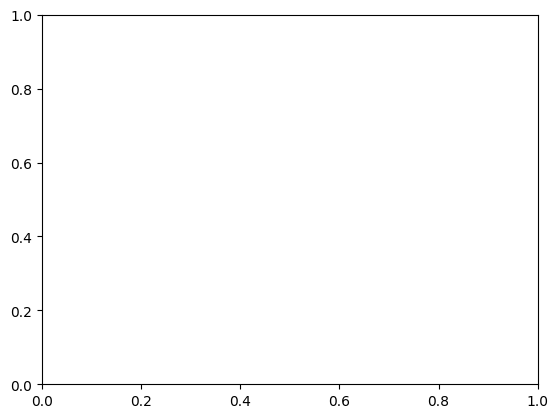

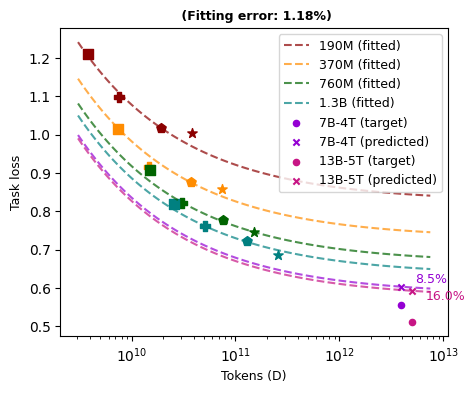

In [35]:
from olmo.scaling.scaling_laws.utils import get_final_configs, get_step1_data_by_name, get_task_sets
from scaling.step1 import main as step1_main
from scaling.step1 import fit_step1, predict_step1, plot_step1, str_chinchilla_n_d_fit

os.chdir('/Users/dhei/ai2/new-evals/olmo-repos/OLMo')

config_path = "scripts/scaling/final.json"
# config_path = "scripts/scaling/final_7b_only.json"

configs = get_final_configs(config_path)
task_names = get_task_sets(["v2_main_variance"])

data_by_name = get_step1_data_by_name(
    configs,
    'arc_easy_test_5shot',
    y_metric='rc_bpb',
    moving_avg=5,
)

fig, axes = plt.subplots(1, 1, figsize=(5, 4), squeeze=False)
ax = axes[0][0]

coefficients, cov = fit_step1(data_by_name, 'rc_bpb')

(
    predicted_data_by_name, plotted_predicted_data,
    (y, y_pred, rel_error), all_rel_errors,
) = predict_step1(
    configs, data_by_name, coefficients, y_metric='rc_bpb', 
)

plot_step1(
    configs, data_by_name, predicted_data_by_name, plotted_predicted_data,
    task_name, str_chinchilla_n_d_fit(coefficients), 'rc_bpb',
    coefficients, cov, ax,
)